In [53]:
import os
import json
import numpy as np
import pandas as pd
import pickle





# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src.config import SUB_PATH, Config as Config  
from src.data_loader import load_data, prepare_data

cfg = Config



KAGGLE_EVAL = cfg.KAGGLE_EVAL
RANDOM_STATE = cfg.RANDOM_STATE
TASK = cfg.TASK
USE_POSTPROCESSING = cfg.USE_POSTPROCESSING
TARGET = cfg.TARGET
ID = cfg.ID
SUB_PATH = cfg.SUB_PATH
SUBMIT_PROBABILITIES = cfg.SUBMIT_PROBABILITIES
metric_name = cfg.LIB_PARAMS["lightgbm"]["metric"]

# -------------------------------------------------------



# -------------------------------
# Load Data
# -------------------------------
X_train, X_test, y_train, y_test = load_data("encoded")
# Prepare
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True # ,label_map = {"A": 1, "B": 0, "C": 2}
)

# Ensure y is numpy array
y_train_numeric = np.array(y_train_numeric)
y_test_numeric = np.array(y_test_numeric) if y_test_numeric is not None else None


from src.data_splitter import DataSplitter


# ⚠️ If you don’t set folds_path, it will generate new random splits every time you call split().
splitter = DataSplitter(
    method="stratified_kfold",
    # method="repeated_stratified",
    n_splits=5,
    random_state=42,
    # n_repeats=10,
    # random_states=[42, 1337],  # multi-seed CV
    folds_path="data/folds.npy"
)

folds = list(splitter.split(X_train, y_train_numeric, reuse_folds=True, verbose=True))



sys.path contains: /home/ismail/Documents/projects/ml-projects/x42
Number of classes: 3
X_train shape: (76518, 36)
X_test shape: (51012, 36)
y_train shape: (76518,)
y_test labels are not available
Test IDs available: 51012
✅ Loaded 5 folds from data/folds.npy
♻️ Reusing existing folds
--- Splitting data ---
Method: stratified_kfold
Number of splits: 5
Random seeds: [42]
Dataset size: 76518
Total folds: 5

Fold 0: Train size=61214, Val size=15304
Fold 1: Train size=61214, Val size=15304
Fold 2: Train size=61214, Val size=15304
Fold 3: Train size=61215, Val size=15303
Fold 4: Train size=61215, Val size=15303


In [54]:
from src.experiment_tracker import load_experiments


experiments = load_experiments(load_models=False, load_preds=True)
for exp in experiments:
    print(exp["name"], exp["metrics"])

✅ Loaded 2 experiments from /home/ismail/Documents/projects/ml-projects/x42/outputs/experiments
20260326-145154_lgbm_CVScore0.4486_exp_20260326-1451_learning_rate0.02757359293934948_max_depth12 {'ROC AUC': 0.9968652472824441, 'Log Loss': 0.16488041234125517, 'Accuracy': 0.9612117410282548}
20260328-164507_xgb_CVScore0.4486_exp_20260328-1645_learning_rate0.02757359293934948_max_depth12 {'ROC AUC': 0.9968652472824441, 'Log Loss': 0.16488041234125517, 'Accuracy': 0.9612117410282548}


In [55]:
# Example: print CV score and model name for all experiments
for exp in experiments:
    print(exp["name"], exp["metadata"].get("cv_score"), exp["metadata"].get("model_name"))

20260326-145154_lgbm_CVScore0.4486_exp_20260326-1451_learning_rate0.02757359293934948_max_depth12 0.4486328848923131 lgbm
20260328-164507_xgb_CVScore0.4486_exp_20260328-1645_learning_rate0.02757359293934948_max_depth12 0.4486328848923131 xgb


In [56]:
# Sort experiments by CV score descending
experiments_sorted = sorted(experiments, key=lambda x: x["metadata"].get("cv_score", 0), reverse=True)

# Show top 5 experiments
for exp in experiments_sorted[:5]:
    print(exp["name"], exp["metadata"]["cv_score"])

20260326-145154_lgbm_CVScore0.4486_exp_20260326-1451_learning_rate0.02757359293934948_max_depth12 0.4486328848923131
20260328-164507_xgb_CVScore0.4486_exp_20260328-1645_learning_rate0.02757359293934948_max_depth12 0.4486328848923131


In [57]:
exp_summary = pd.DataFrame([
    {
        "name": exp["name"],
        "model": exp["metadata"].get("model_name"),
        "cv_score": exp["metadata"].get("cv_score"),
        "train_samples": exp["metadata"].get("num_samples"),
        "num_features": exp["metadata"].get("num_features"),
    }
    for exp in experiments
])

exp_summary.sort_values("cv_score", ascending=False)

,name,model,cv_score,train_samples,num_features
0,20260326-145154_lgbm_CVScore0.4486_exp_2026032...,lgbm,0.448633,76518,36
1,20260328-164507_xgb_CVScore0.4486_exp_20260328...,xgb,0.448633,76518,36


In [58]:
# Assuming your experiments are in a variable called `experiments`
exp_summary = pd.DataFrame([
    {
        "name": exp["name"],
        "model": exp["metadata"].get("model_name"),
        "cv_score": exp["metadata"].get("cv_score"),
        "roc_auc": exp["metrics"].get("ROC AUC"),
        "log_loss": exp["metrics"].get("Log Loss"),
        "accuracy": exp["metrics"].get("Accuracy"),
        "max_depth": exp["params"].get("max_depth"),
        "num_leaves": exp["params"].get("num_leaves"),
        "learning_rate": exp["params"].get("learning_rate"),
        "train_time_s": exp["metadata"].get("train_time_seconds"),
        "num_samples": exp["metadata"].get("num_samples"),
        "num_features": exp["metadata"].get("num_features"),
        "path": exp["path"]
    }
    for exp in experiments
])

# Sort by CV score
exp_summary = exp_summary.sort_values("cv_score", ascending=False).reset_index(drop=True)
exp_summary.head(10)

,name,model,cv_score,roc_auc,log_loss,accuracy,max_depth,num_leaves,learning_rate,train_time_s,num_samples,num_features,path
0,20260326-145154_lgbm_CVScore0.4486_exp_2026032...,lgbm,0.448633,0.996865,0.16488,0.961212,12,None,0.027574,441.144812,76518,36,/home/ismail/Documents/projects/ml-projects/x4...
1,20260328-164507_xgb_CVScore0.4486_exp_20260328...,xgb,0.448633,0.996865,0.16488,0.961212,12,None,0.027574,660.494967,76518,36,/home/ismail/Documents/projects/ml-projects/x4...


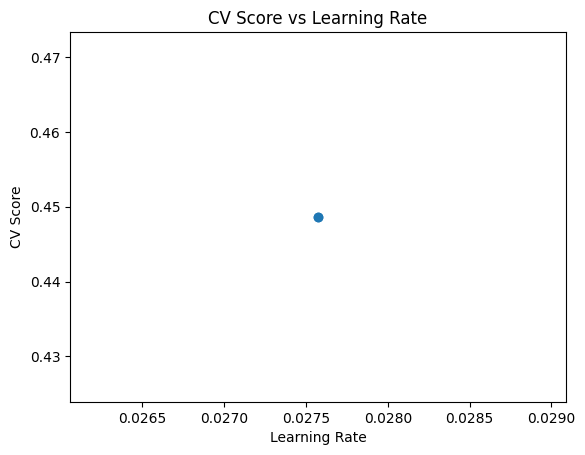

In [59]:
import matplotlib.pyplot as plt

plt.scatter(exp_summary["learning_rate"], exp_summary["cv_score"])
plt.xlabel("Learning Rate")
plt.ylabel("CV Score")
plt.title("CV Score vs Learning Rate")
plt.show()

In [60]:
# Collect OOF predictions for all experiments
oof_dfs = []
for exp in experiments:
    df = pd.DataFrame(exp["oof_postprocessed_preds"], columns=[f"{exp['name']}_class0",
                                                               f"{exp['name']}_class1",
                                                               f"{exp['name']}_class2"])
    oof_dfs.append(df)

# Combine all OOF predictions
oof_combined = pd.concat(oof_dfs, axis=1)
oof_combined.head()

,20260326-145154_lgbm_CVScore0.4486_exp_20260326-1451_learning_rate0.02757359293934948_max_depth12_class0,20260326-145154_lgbm_CVScore0.4486_exp_20260326-1451_learning_rate0.02757359293934948_max_depth12_class1,20260326-145154_lgbm_CVScore0.4486_exp_20260326-1451_learning_rate0.02757359293934948_max_depth12_class2,20260328-164507_xgb_CVScore0.4486_exp_20260328-1645_learning_rate0.02757359293934948_max_depth12_class0,20260328-164507_xgb_CVScore0.4486_exp_20260328-1645_learning_rate0.02757359293934948_max_depth12_class1,20260328-164507_xgb_CVScore0.4486_exp_20260328-1645_learning_rate0.02757359293934948_max_depth12_class2
0,0.006354,0.027611,0.966035,0.006354,0.027611,0.966035
1,0.935378,0.059124,0.005498,0.935378,0.059124,0.005498
2,0.993942,0.003666,0.002392,0.993942,0.003666,0.002392
3,0.028371,0.147810,0.823818,0.028371,0.147810,0.823818
4,0.042840,0.471424,0.485736,0.042840,0.471424,0.485736


NameError: name 'load_data' is not defined

In [76]:
# -----------------------------
# 1️⃣ Import packages
# -----------------------------
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier

# For your custom evaluation (optional)
from src.evaluation_utils import evaluate_metric

# -----------------------------
# 2️⃣ Select your experiments
# -----------------------------
selected_exps = experiments[:4]  # pick top models based on score

# -----------------------------
# 3️⃣ Build meta-features
# -----------------------------
def build_meta_dataframe(experiments, use_oof=True):
    dfs = []
    for i, exp in enumerate(experiments):
        name = exp["name"]
        preds = exp["oof_preds"] if use_oof else exp["test_preds"]
        n_classes = preds.shape[1]
        cols = [f"{name}_class_{j}" for j in range(n_classes)]
        df = pd.DataFrame(preds, columns=cols)
        dfs.append(df)
    meta_df = pd.concat(dfs, axis=1)
    return meta_df

X_meta_df = build_meta_dataframe(selected_exps, use_oof=True)
X_test_meta_df = build_meta_dataframe(selected_exps, use_oof=False)

print("Meta train shape:", X_meta_df.shape)
print("Meta test shape:", X_test_meta_df.shape)

# Optional: Add original features for stronger stacking
# X_meta_df = pd.concat([X_meta_df, X_train.reset_index(drop=True)], axis=1)
# X_test_meta_df = pd.concat([X_test_meta_df, X_test.reset_index(drop=True)], axis=1)

# -----------------------------
# 4️⃣ Proper CV stacking (OOF)
# -----------------------------
def train_meta_cv(X_meta, y, X_test_meta, n_splits=5, use_lgbm=False):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    n_classes = len(np.unique(y))
    
    oof_meta = np.zeros((len(X_meta), n_classes))
    test_meta = np.zeros((len(X_test_meta), n_classes))
    
    for fold, (train_idx, valid_idx) in enumerate(folds):
        print(f"Meta Fold {fold+1}")
        
        X_tr, X_val = X_meta.iloc[train_idx], X_meta.iloc[valid_idx]
        y_tr, y_val = y[train_idx], y[valid_idx]

        # Choose meta-model
        if use_lgbm:
            model = LGBMClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        else:
            model = LogisticRegression(max_iter=1000, C=1.0)
        
        model.fit(X_tr, y_tr)

        # OOF predictions
        oof_meta[valid_idx] = model.predict_proba(X_val)

        # Test predictions (average over folds)
        test_meta += model.predict_proba(X_test_meta) / n_splits

    return oof_meta, test_meta

# -----------------------------
# 5️⃣ Train meta-model
# -----------------------------
oof_meta, test_meta = train_meta_cv(
    X_meta_df,
    y_train_numeric,
    X_test_meta_df,
    n_splits=5,
    use_lgbm=False  # set True for LGBM, False for LogisticRegression
)

# -----------------------------
# 6️⃣ Evaluate stacking
# -----------------------------
pred_classes = np.argmax(oof_meta, axis=1)

# Using sklearn metric
score = accuracy_score(y_train_numeric, pred_classes)
print("STACKING SCORE (sklearn):", score)

# Optional: your custom evaluation function
score_custom = evaluate_metric(
    y_true=y_train_numeric,
    y_input=oof_meta,
    task="multiclass",
    kaggle_eval="accuracy"
)
print("STACKING SCORE (custom):", score_custom)

# -----------------------------
# 7️⃣ Make predictions for submission
# -----------------------------
test_pred_classes = np.argmax(test_meta, axis=1)
submission = pd.DataFrame({
    "id": test_ids,
    "target": test_pred_classes
})
# submission.to_csv("stacking_submission.csv", index=False)
print("Submission saved!")

Meta train shape: (76518, 6)
Meta test shape: (51012, 6)
Meta Fold 1
Meta Fold 2
Meta Fold 3
Meta Fold 4
Meta Fold 5
STACKING SCORE (sklearn): 0.8305235369455553
STACKING SCORE (custom): 0.8305235369455553
Submission saved!


In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from src.evaluation_utils import evaluate_metric
from pathlib import Path

class StackingEngine:
    """
    Advanced stacking engine for OOF-based stacking.
    Supports multi-class classification, dynamic base models, 
    custom meta-models, and fold reuse.
    """

    def __init__(self, base_models, meta_model, folds, task="multiclass", metric="accuracy"):
        """
        base_models: list of dicts {"name": str, "model": sklearn model, "oof_preds": np.array, "test_preds": np.array (optional)}
        meta_model: sklearn-like model for stacking
        folds: list of (train_idx, val_idx) tuples from DataSplitter
        task: "multiclass" or "regression"
        metric: metric name for evaluation
        """
        self.base_models = base_models
        self.meta_model = meta_model
        self.folds = folds
        self.task = task
        self.metric = metric

    def build_meta_dataframe(self, use_oof=True):
        """
        Concatenate all base model predictions into a meta-feature DataFrame.
        use_oof: If True, uses oof_preds, else uses test_preds
        """
        dfs = []
        for exp in self.base_models:
            name = exp["name"]
            preds = exp["oof_preds"] if use_oof else exp.get("test_preds", None)
            if preds is None:
                raise ValueError(f"{name} does not have {'OOF' if use_oof else 'test'} predictions")
            
            n_classes = preds.shape[1]
            cols = [f"{name}_class_{j}" for j in range(n_classes)]
            df = pd.DataFrame(preds, columns=cols)
            dfs.append(df)
        
        meta_df = pd.concat(dfs, axis=1)
        return meta_df

    def fit_meta_model(self, X_meta, y):
        """
        Fit meta-model using OOF strategy to avoid leakage.
        Returns OOF predictions for training set.
        """
        oof_pred_meta = np.zeros((len(y), self.base_models[0]["oof_preds"].shape[1]))

        for fold, (train_idx, val_idx) in enumerate(self.folds):
            X_tr, X_val = X_meta.iloc[train_idx], X_meta.iloc[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]
            
            model = clone(self.meta_model)
            model.fit(X_tr, y_tr)
            
            oof_pred_meta[val_idx] = model.predict_proba(X_val)
        
        score = evaluate_metric(y_true=y, y_input=oof_pred_meta, task=self.task, kaggle_eval=self.metric)
        print(f"STACKING OOF SCORE: {score:.4f}")
        self.meta_model.fit(X_meta, y)  # final fit on full meta-data
        return oof_pred_meta

    def predict(self, X_meta):
        """
        Predict on meta-features using trained meta-model
        """
        return self.meta_model.predict_proba(X_meta)

    def run(self, y_train):
        """
        Full stacking workflow
        """
        X_meta_df = self.build_meta_dataframe(use_oof=True)
        oof_pred_meta = self.fit_meta_model(X_meta_df, y_train)
        X_test_meta_df = self.build_meta_dataframe(use_oof=False)
        test_pred_meta = self.predict(X_test_meta_df)
        return oof_pred_meta, test_pred_meta, X_meta_df, X_test_meta_df
    
    # add
    # Dynamic base model selection
    # Weighted predictions / Optuna optimization
    # Multi-level stacking
    # Custom meta-models + original features
    # Fold reuse and multi-seed CV
    # Prediction calibration
    # Parallel fold training
    # Feature engineering for meta-model

selected_exps = experiments[:4]  # top base models


from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(max_iter=1000)

stack_engine = StackingEngine(
    base_models=selected_exps,
    meta_model=meta_model,
    folds=folds,
    task="multiclass",
    metric="accuracy"
)

oof_pred_meta, test_pred_meta, X_meta_df, X_test_meta_df = stack_engine.run(y_train_numeric)

STACKING OOF SCORE: 0.8305


In [82]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from src.evaluation_utils import evaluate_metric
from pathlib import Path
from joblib import Parallel, delayed
import optuna

class AdvancedStackingEngine:
    """
    Fully advanced stacking engine with:
    - OOF-based stacking
    - Weighted base models (optimized with Optuna)
    - Multi-class / regression
    - Dynamic base model selection
    - Multi-seed CV support
    - Optional feature engineering
    """

    def __init__(
        self,
        base_models,
        meta_model,
        folds,
        task="multiclass",
        metric="accuracy",
        use_weights=True,
        feature_engineering=False,
        n_jobs=1,
        seed=42
    ):
        self.base_models = base_models
        self.meta_model = meta_model
        self.folds = folds
        self.task = task
        self.metric = metric
        self.use_weights = use_weights
        self.feature_engineering = feature_engineering
        self.n_jobs = n_jobs
        self.seed = seed
        self.opt_weights = np.ones(len(base_models))  # default

    def build_meta_dataframe(self, use_oof=True, weights=None):
        dfs = []
        for i, exp in enumerate(self.base_models):
            name = exp["name"]
            preds = exp["oof_preds"] if use_oof else exp.get("test_preds")
            if preds is None:
                raise ValueError(f"{name} does not have {'OOF' if use_oof else 'test'} predictions")
            
            # Apply weights if provided
            if weights is not None:
                preds = preds * weights[i]
            
            n_classes = preds.shape[1]
            cols = [f"{name}_class_{j}" for j in range(n_classes)]
            df = pd.DataFrame(preds, columns=cols)
            dfs.append(df)

        meta_df = pd.concat(dfs, axis=1)

        if self.feature_engineering:
            meta_df["max_prob_diff"] = meta_df.max(axis=1) - meta_df.apply(lambda row: np.partition(row.values, -2)[-2], axis=1)
            meta_df["mean_prob"] = meta_df.mean(axis=1)
            meta_df["std_prob"] = meta_df.std(axis=1)

        return meta_df

    def _fit_fold(self, X_meta, y, train_idx, val_idx):
        X_tr, X_val = X_meta.iloc[train_idx], X_meta.iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = clone(self.meta_model)
        model.fit(X_tr, y_tr)
        pred_val = model.predict_proba(X_val) if self.task == "multiclass" else model.predict(X_val)
        return val_idx, pred_val, model

    def fit_meta_model(self, X_meta, y):
        n_classes = self.base_models[0]["oof_preds"].shape[1] if self.task == "multiclass" else 1
        oof_pred_meta = np.zeros((len(y), n_classes))

        results = Parallel(n_jobs=self.n_jobs)(
            delayed(self._fit_fold)(X_meta, y, train_idx, val_idx)
            for train_idx, val_idx in self.folds
        )

        for val_idx, pred_val, _ in results:
            oof_pred_meta[val_idx] = pred_val

        score = evaluate_metric(y_true=y, y_input=oof_pred_meta, task=self.task, kaggle_eval=self.metric)
        print(f"STACKING OOF SCORE: {score:.4f}")

        # Final fit on full meta-data
        self.meta_model.fit(X_meta, y)
        return oof_pred_meta

    def predict(self, X_meta):
        return self.meta_model.predict_proba(X_meta) if self.task == "multiclass" else self.meta_model.predict(X_meta)

    # ---------------- Optuna for weight optimization ----------------
    def optimize_weights(self, y_train, n_trials=50):
        def objective(trial):
            weights = [trial.suggest_float(f"w{i}", 0.0, 2.0) for i in range(len(self.base_models))]
            X_meta = self.build_meta_dataframe(use_oof=True, weights=weights)
            n_classes = self.base_models[0]["oof_preds"].shape[1] if self.task == "multiclass" else 1
            oof_pred_meta = np.zeros((len(y_train), n_classes))

            for train_idx, val_idx in self.folds:
                X_tr, X_val = X_meta.iloc[train_idx], X_meta.iloc[val_idx]
                y_tr, y_val = y_train[train_idx], y_train[val_idx]

                model = clone(self.meta_model)
                model.fit(X_tr, y_tr)
                pred_val = model.predict_proba(X_val) if self.task == "multiclass" else model.predict(X_val)
                oof_pred_meta[val_idx] = pred_val

            score = evaluate_metric(y_true=y_train, y_input=oof_pred_meta, task=self.task, kaggle_eval=self.metric)
            return score  # Optuna will maximize this

        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=n_trials, n_jobs=self.n_jobs)
        self.opt_weights = np.array([study.best_params[f"w{i}"] for i in range(len(self.base_models))])
        print(f"Optimal weights found: {self.opt_weights}")
        return self.opt_weights

    def run(self, y_train, optimize=True, n_trials=50):
        """
        Full stacking workflow with optional weight optimization
        """
        if self.use_weights and optimize:
            self.optimize_weights(y_train, n_trials=n_trials)
        
        X_meta_df = self.build_meta_dataframe(use_oof=True, weights=self.opt_weights if self.use_weights else None)
        oof_pred_meta = self.fit_meta_model(X_meta_df, y_train)
        X_test_meta_df = self.build_meta_dataframe(use_oof=False, weights=self.opt_weights if self.use_weights else None)
        test_pred_meta = self.predict(X_test_meta_df)
        return oof_pred_meta, test_pred_meta, X_meta_df, X_test_meta_df
    



from sklearn.linear_model import LogisticRegression

selected_exps = experiments[:4]  # top base models
meta_model = LogisticRegression(max_iter=1000)

stack_engine = AdvancedStackingEngine(
    base_models=selected_exps,
    meta_model=meta_model,
    folds=folds,
    task="multiclass",
    metric="accuracy",
    use_weights=True,
    feature_engineering=True,
    n_jobs=4
)

oof_pred_meta, test_pred_meta, X_meta_df, X_test_meta_df = stack_engine.run(
    y_train_numeric, optimize=True, n_trials=30
)

[I 2026-03-28 17:15:10,710] A new study created in memory with name: no-name-7711a810-4439-4e89-ad8c-1b5bc864c841
[I 2026-03-28 17:15:16,313] Trial 1 finished with value: 0.8303536422802478 and parameters: {'w0': 1.0424543498921373, 'w1': 1.1971745605930086}. Best is trial 1 with value: 0.8303536422802478.
[I 2026-03-28 17:15:16,420] Trial 0 finished with value: 0.8301576099741237 and parameters: {'w0': 1.4557244868586494, 'w1': 1.9538995577757183}. Best is trial 1 with value: 0.8303536422802478.
[I 2026-03-28 17:15:16,661] Trial 3 finished with value: 0.8300922658720824 and parameters: {'w0': 0.3956080459930009, 'w1': 0.621424874803409}. Best is trial 1 with value: 0.8303536422802478.
[I 2026-03-28 17:15:16,880] Trial 2 finished with value: 0.8302490917169816 and parameters: {'w0': 0.7482873942458261, 'w1': 1.2166800300940284}. Best is trial 1 with value: 0.8303536422802478.
[I 2026-03-28 17:15:21,770] Trial 7 finished with value: 0.830026921770041 and parameters: {'w0': 1.00837248532

Optimal weights found: [0.66954176 1.8477834 ]
STACKING OOF SCORE: 0.8305


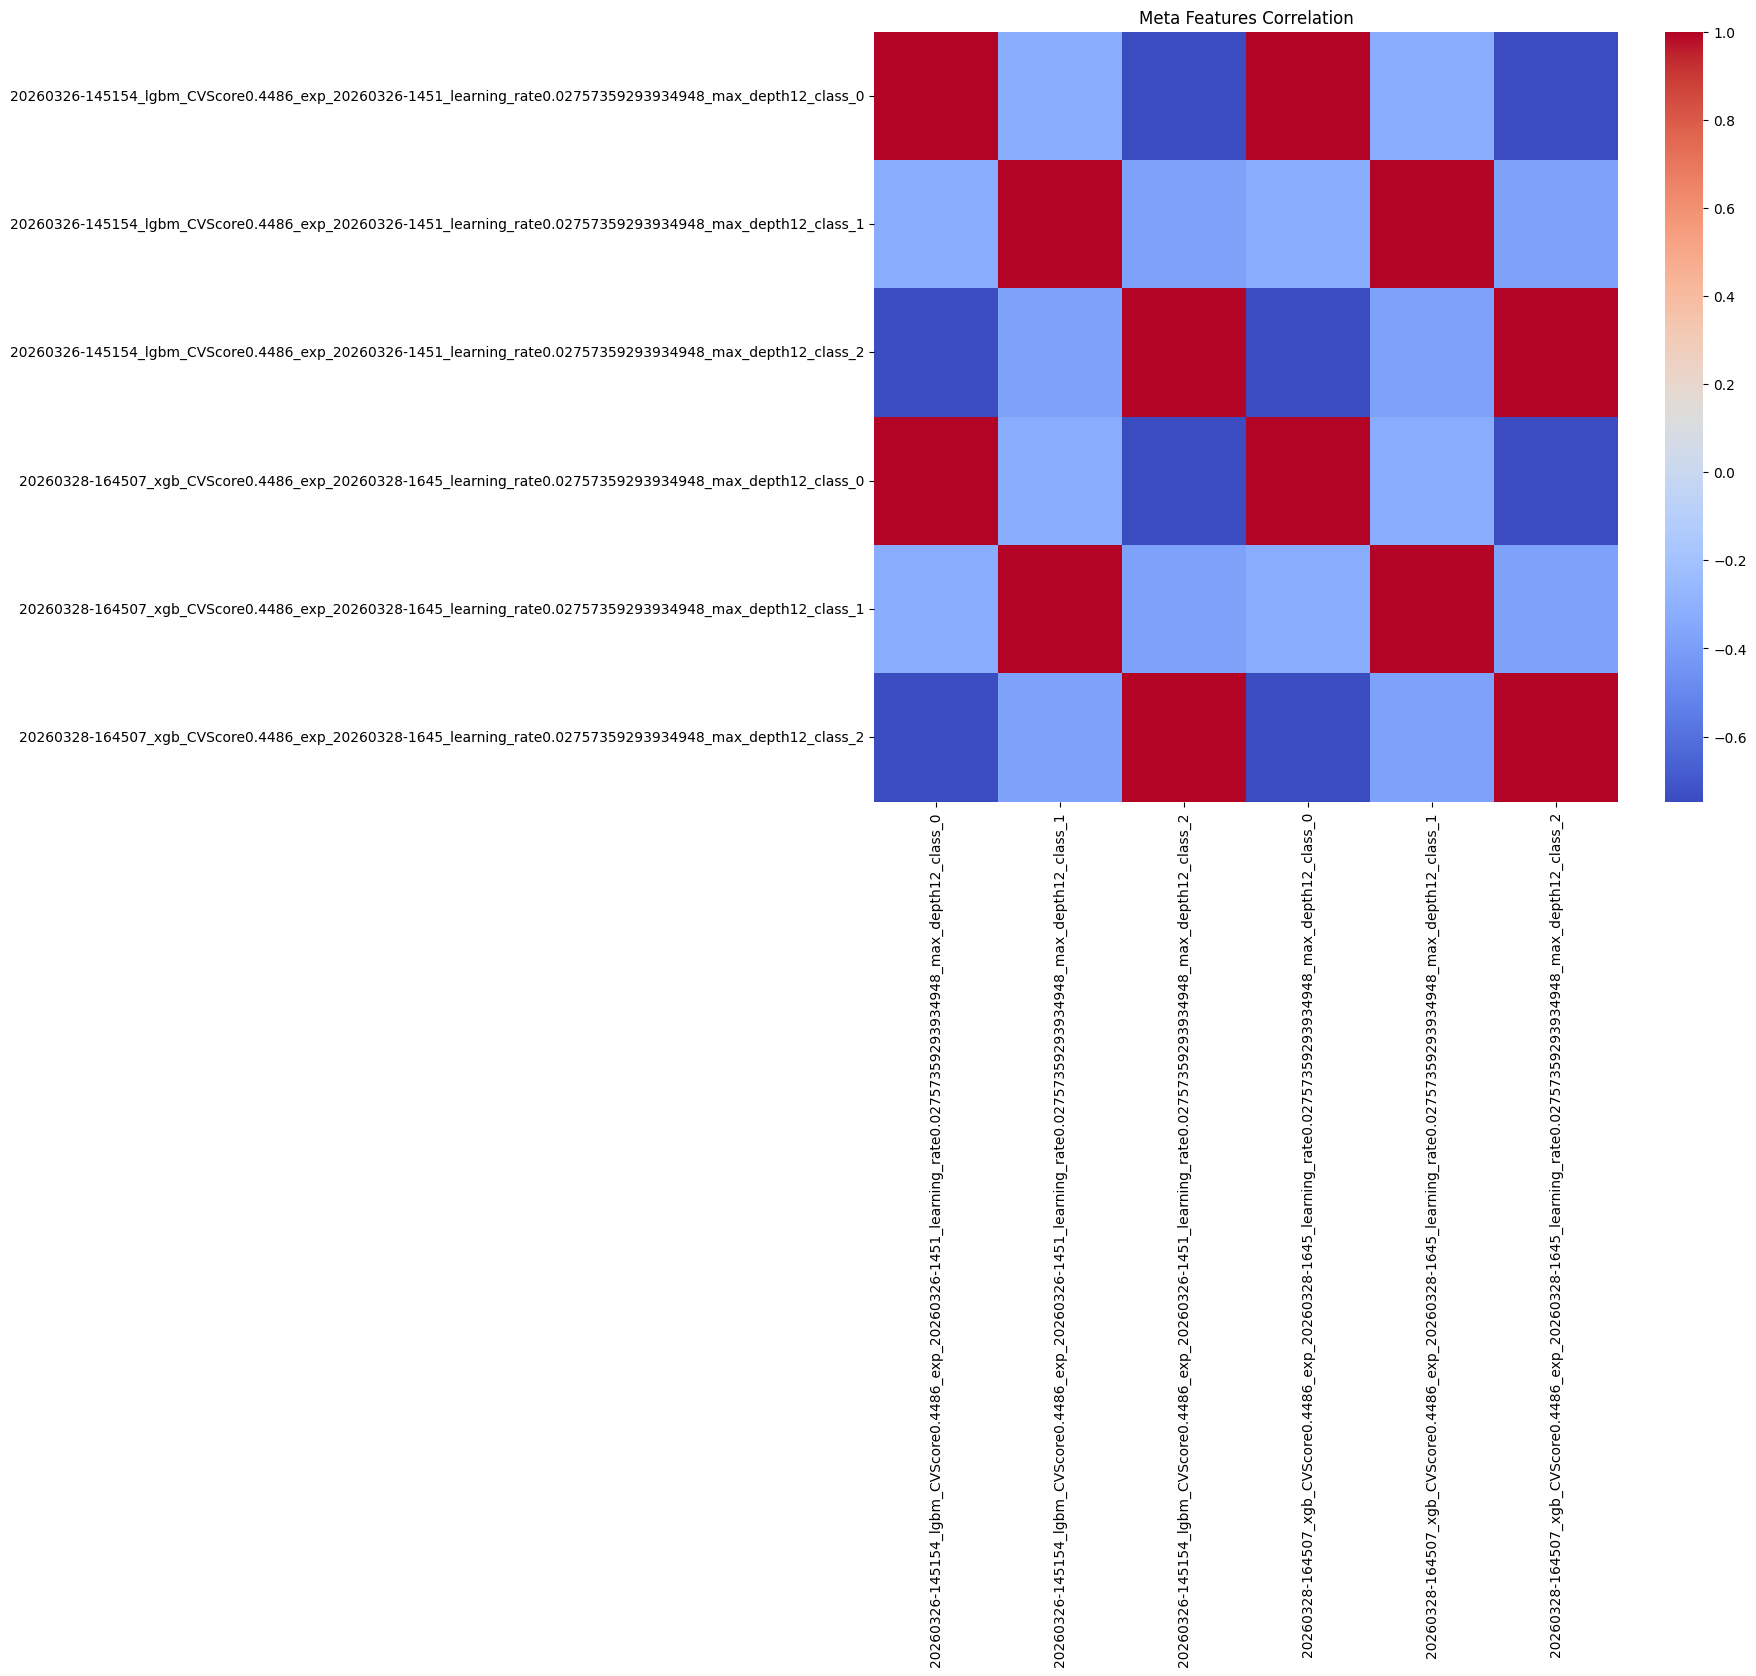

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X_meta_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Meta Features Correlation")
plt.show()

<mark>automatic ensemble optimizer (Optuna for weights)??????</mark>

<mark>Weighted stacking using Optuna to find the best combination of base model weights.???</mark>

Basic:
X_meta = concat([oof_model1, oof_model2, ...])
Advanced:

Add features like:

max_prob = oof_preds.max(axis=1)
entropy = -np.sum(p * log(p))
confidence_gap = top1 - top2

👉 These improve meta-model a LOT.

Ah! If your goal is to **ensemble multiple models for tabular data (like in your LightGBM / XGBoost project)**, here’s a structured list of the **best and commonly used methods**, with their pros, cons, and when to use them. I’ll separate them by type: **stacking, blending, bagging, boosting, and post-processing**.

---

## **1️⃣ Stacking (meta-model)**

**How it works:**

* Train multiple **base models** on the training data.
* Get **OOF predictions** from base models → these form the training set for the **meta-model**.
* Train a **meta-model** (often LogisticRegression for binary/multiclass) on OOF predictions.
* Predict on test set using base models trained on **full training data** → feed into meta-model.

**Pros:**

* Adapts to base models’ weaknesses.
* Often improves over simple averaging.

**Cons:**

* Slightly more complex to implement.
* Needs OOF predictions to avoid data leakage.

**Tips:**

* Use **diverse base models** (tree-based + linear + neural network).
* Don’t use too many base models; 3–5 strong ones are usually enough.
* Meta-model is usually simple (logistic, ridge, small NN).

---

## **2️⃣ Simple Averaging / Weighted Averaging**

**How it works:**

* Train base models on **full training data**.
* Predict on test set.
* Take **average** (or weighted average) of probabilities.

**Pros:**

* Very simple to implement.
* Works well if base models are already strong and somewhat independent.

**Cons:**

* Doesn’t adapt to base models’ strengths/weaknesses like stacking.

**Tips:**

* Weight models according to **CV performance** (better models → higher weight).
* Works best if base models’ errors are **uncorrelated**.

---

## **3️⃣ Blending (simpler stacking)**

**How it works:**

* Hold out a small **validation set** from training data.
* Train base models on the rest, predict on the hold-out set.
* Use these predictions to train a **meta-model**.
* Predict on test set using base models trained on **full training data**.

**Pros:**

* Simpler than full stacking with K-Folds.
* Less computationally expensive than OOF stacking.

**Cons:**

* Less robust, because meta-model sees only a small validation set → risk of overfitting.

---

## **4️⃣ Bagging / Bootstrap Aggregation**

**How it works:**

* Train multiple instances of the **same model** on different **random subsets** of training data.
* Average their predictions (for regression) or majority vote (for classification).

**Pros:**

* Reduces variance → more stable predictions.
* Good for tree-based models (RandomForest is bagging of Decision Trees).

**Cons:**

* Doesn’t improve bias → won’t help if the base model is underfitting.

**Tips:**

* Can combine different seeds of LightGBM/XGBoost models as a bagging ensemble.

---

## **5️⃣ Boosting (not traditional ensemble)**

**How it works:**

* Sequentially train models where each next model tries to fix the previous model’s errors.
* Examples: LightGBM, XGBoost, CatBoost.

**Pros:**

* Often strong baseline for tabular data.

**Cons:**

* Base models are **dependent**, not truly “ensembleable” further unless you do stacking.

---

## **6️⃣ Post-processing / Calibration Ensembles**

**How it works:**

* After base model predictions or stacking, **tune thresholds or scales** to improve metrics.
* Examples: Platt scaling, isotonic regression, or your `optimize_postprocessing()` function.

**Pros:**

* Can improve probabilistic predictions (ROC-AUC, log-loss).

**Cons:**

* Doesn’t fix base model mistakes; only improves output probabilities.

---

## **7️⃣ Diversity is Key**

Regardless of method, the **best ensembles** often share these principles:

1. Use **different algorithms** (LightGBM + XGBoost + CatBoost + neural nets).
2. Use **different feature sets** (feature engineering diversity).
3. Use **different hyperparameters** (e.g., shallow vs deep trees).
4. Combine **stacking with averaging**: sometimes a meta-model + final weighted average works best.

---

### **📌 Practical Recommendations for Your Project**

For your `ensemble.ipynb`:

1. **Stacking with OOF predictions** → primary ensemble method.
2. Optional **weighted average of base models** → fallback/simple submission.
3. **Post-processing on OOF/test predictions** → always check for ROC-AUC/log-loss improvements.
4. Keep **meta-model simple** (logistic regression or ridge).

---

If you want, I can make a **diagram showing exactly how your LightGBM + XGBoost + CatBoost models → OOF → meta-model → test predictions** ensemble should flow. This is super useful for your `ensamble.ipynb`.

Do you want me to do that?


# rank ensembling.
<mark>this is good to improve AUC</mark>


Remember: competitions using ROC AUC only care about **ranking**, not the exact probability values.

---

# 1️⃣ What AUC actually checks

AUC only checks:

> **Are positive samples ranked higher than negative samples?**

Example:

| Sample | True label | Prediction |
| ------ | ---------- | ---------- |
| A      | 1          | 0.9        |
| B      | 0          | 0.6        |
| C      | 1          | 0.5        |
| D      | 0          | 0.2        |

Model ranking:

```
A > B > C > D
```

But the correct ranking should be:

```
A > C > B > D
```

Because **C is positive but ranked below B**.

AUC penalizes that mistake.

---

# 2️⃣ Why we combine multiple models

Suppose you train two models.

### Model 1

| Sample | Prediction |
| ------ | ---------- |
| A      | 0.9        |
| B      | 0.7        |
| C      | 0.4        |
| D      | 0.2        |

Ranking:

```
A > B > C > D
```

Mistake: **B ranked above C**

---

### Model 2

| Sample | Prediction |
| ------ | ---------- |
| A      | 0.8        |
| B      | 0.3        |
| C      | 0.6        |
| D      | 0.1        |

Ranking:

```
A > C > B > D
```

This model fixes the mistake.

---

# 3️⃣ If we average probabilities

Normal ensembling:

```
(A): (0.9 + 0.8)/2 = 0.85
(B): (0.7 + 0.3)/2 = 0.50
(C): (0.4 + 0.6)/2 = 0.50
(D): (0.2 + 0.1)/2 = 0.15
```

Ranking becomes:

```
A > B ≈ C > D
```

Not great.

---

# 4️⃣ Rank averaging (the trick)

Instead of averaging probabilities, we average **ranks**.

### Model 1 ranks

| Sample | Rank |
| ------ | ---- |
| A      | 4    |
| B      | 3    |
| C      | 2    |
| D      | 1    |

---

### Model 2 ranks

| Sample | Rank |
| ------ | ---- |
| A      | 4    |
| C      | 3    |
| B      | 2    |
| D      | 1    |

---

### Average ranks

| Sample | Avg rank |
| ------ | -------- |
| A      | 4        |
| C      | 2.5      |
| B      | 2.5      |
| D      | 1        |

Final ranking:

```
A > C ≈ B > D
```

Now **C moves higher**, improving ranking.

---

# 5️⃣ Why this works

Different models make **different ranking mistakes**.

Rank averaging:

* reduces noise
* keeps consistent ordering
* improves AUC stability

This is why top competitors on Kaggle often ensemble **10–30 models**.

---

# 6️⃣ Practical Python example

```python
from scipy.stats import rankdata
import numpy as np

rank1 = rankdata(pred_model1)
rank2 = rankdata(pred_model2)

final_prediction = (rank1 + rank2) / 2
```

Submit `final_prediction`.

---

# 7️⃣ Important detail

Rank averaging is especially useful when models have **different scales**.

Example:

| Model          | Output scale |
| -------------- | ------------ |
| LightGBM       | 0–1          |
| Neural network | 0–0.2        |
| SVM            | -3 to 3      |

Averaging probabilities would be bad.

But **ranks normalize everything automatically**.

---

✅ **Simple intuition**

Instead of averaging **scores**, we average **positions in the ranking**.

---

If you want, I can also explain a **very powerful Kaggle technique called "Out-of-Fold (OOF) stacking"**.

That method is used in **almost every winning solution** and works perfectly with what you're already doing with Optuna + LightGBM.
